In [16]:
# === 1. Imports & configuration ===
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

CSV_PATH    = Path("/srv/disk00/ctadler/gift-eval/results/Moiraic/all_results.csv")
metric_cols = {
    "eval_metrics/MSE[mean]":                     "MSE",
    "eval_metrics/MAE[0.5]":                      "MAE",
    "eval_metrics/MASE[0.5]":                     "MASE",
    "eval_metrics/MAPE[0.5]":                     "MAPE",
    "eval_metrics/sMAPE[0.5]":                    "sMAPE",
    "eval_metrics/MSIS":                          "MSIS",
    "eval_metrics/RMSE[mean]":                    "RMSE",
    "eval_metrics/NRMSE[mean]":                   "NRMSE",
    "eval_metrics/ND[0.5]":                       "ND",
    "eval_metrics/mean_weighted_sum_quantile_loss": "WQL",
}
PRIMARY_METRIC = 'eval_metrics/MASE[0.5]'   # robust default; change if needed
# PRIMARY_METRIC = "eval_metrics/mean_weighted_sum_quantile_loss"

# Metrics where lower = better (default for forecasting error metrics)
LOWER_IS_BETTER = True

In [17]:

# === 2. Load + parse dataset string ===
df = pd.read_csv(CSV_PATH)

def parse_dataset(s):
    parts = str(s).split('/')
    if len(parts) == 3:
        return pd.Series({'dataset_name': parts[0], 'freq': parts[1], 'horizon': parts[2]})
    if len(parts) == 2:
        return pd.Series({'dataset_name': parts[0], 'freq': parts[1], 'horizon': 'short'})
    return pd.Series({'dataset_name': parts[0], 'freq': np.nan, 'horizon': np.nan})

df = df.join(df['dataset'].apply(parse_dataset))

# Order categorical horizon: short < medium < long
df['horizon'] = pd.Categorical(df['horizon'], categories=['short','medium','long'], ordered=True)

# Map freq codes to granularity buckets for readability
FREQ_BUCKET = {
    '5T':'sub-hourly','10T':'sub-hourly','15T':'sub-hourly','10S':'sub-hourly','30T':'sub-hourly',
    'H':'hourly','D':'daily','W':'weekly','M':'monthly','Q':'quarterly','A':'yearly'
}
df['granularity'] = df['freq'].map(FREQ_BUCKET).fillna(df['freq'])

metric_cols = [c for c in df.columns if c.startswith('eval_metrics/')]
print(f'Loaded {len(df)} rows · {df["model"].nunique()} models · {df["dataset_name"].nunique()} datasets')
print('Models:', sorted(df['model'].unique()))
print('Domains:', sorted(df['domain'].unique()))
df.head()

Loaded 388 rows · 4 models · 28 datasets
Models: ['moiraic_base_11', 'moiraie_base_7', 'moiraie_base_8', 'moiraie_base_9']
Domains: ['Econ/Fin', 'Energy', 'Healthcare', 'Nature', 'Sales', 'Transport', 'Web/CloudOps']


,dataset,model,eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,domain,num_variates,dataset_name,freq,horizon,granularity
0,bitbrains_fast_storage/5T/long,moiraic_base_11,4.525709e+06,4.525709e+06,355.606051,0.963014,4.442060,0.821404,22.339332,2127.371428,5.622007,0.939761,0.773040,Web/CloudOps,2,bitbrains_fast_storage,5T,long,sub-hourly
1,bitbrains_fast_storage/5T/medium,moiraic_base_11,3.438710e+06,3.438710e+06,295.683216,1.044824,4.702778,0.806049,26.124443,1854.375904,5.634106,0.898367,0.688865,Web/CloudOps,2,bitbrains_fast_storage,5T,medium,sub-hourly
2,bitbrains_fast_storage/5T/short,moiraic_base_11,1.774861e+06,1.774861e+06,163.600943,0.732269,1.928368,0.748537,15.259756,1332.239095,4.182901,0.513666,0.398875,Web/CloudOps,2,bitbrains_fast_storage,5T,short,sub-hourly
3,bitbrains_fast_storage/H/short,moiraic_base_11,2.362484e+06,2.362484e+06,270.508197,1.020619,2.559554,0.589661,21.432511,1537.037462,4.381056,0.771036,0.588544,Web/CloudOps,2,bitbrains_fast_storage,H,short,hourly
4,bitbrains_rnd/5T/long,moiraic_base_11,3.044137e+06,3.044137e+06,212.490956,3.473992,2.755481,0.705107,123.354323,1744.745553,6.683727,0.814005,0.732937,Web/CloudOps,2,bitbrains_rnd,5T,long,sub-hourly


In [18]:
# df_short = df.loc[(df["horizon"]=="short") & ((df["model"] == "moiraic_base_11") | (df["model"] == "moiraie_base_7"))]
df_short = df.loc[((df["model"] == "moiraic_base_11") | (df["model"] == "moiraie_base_7"))]
df_short.head()
df = df_short

In [19]:
coverage = df.groupby(['dataset','model']).size().unstack(fill_value=0)
print('Datasets missing a model entry:', int((coverage == 0).any(axis=1).sum()))

bad = df[metric_cols].replace([np.inf, -np.inf], np.nan).isna().sum()
print('\nNaN/inf counts per metric:')
print(bad[bad > 0])

if 'eval_metrics/MAPE[0.5]' in df.columns:
    big = df[df['eval_metrics/MAPE[0.5]'] > 100][['dataset','model','eval_metrics/MAPE[0.5]']]
    if len(big):
        print('\n⚠ Rows with MAPE > 100 (near-zero targets, exclude from MAPE-based summaries):')
        print(big.to_string(index=False))

Datasets missing a model entry: 0

NaN/inf counts per metric:
Series([], dtype: int64)

⚠ Rows with MAPE > 100 (near-zero targets, exclude from MAPE-based summaries):
           dataset           model  eval_metrics/MAPE[0.5]
       ett1/H/long moiraic_base_11            3.542877e+12
     ett1/H/medium moiraic_base_11            2.975986e+12
  sz_taxi/15T/long moiraic_base_11            7.856637e+12
sz_taxi/15T/medium moiraic_base_11            1.210238e+13
 sz_taxi/15T/short moiraic_base_11            1.152102e+12
       ett1/H/long  moiraie_base_7            4.320361e+12
     ett1/H/medium  moiraie_base_7            4.813955e+12
  sz_taxi/15T/long  moiraie_base_7            7.891323e+12
sz_taxi/15T/medium  moiraie_base_7            1.153995e+13
 sz_taxi/15T/short  moiraie_base_7            1.096838e+12


In [20]:
def geo_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    return float(np.exp(np.log(x).mean())) if len(x) else np.nan

def summarize(df, metric, lower_better=True):
    pivot = df.pivot_table(index='dataset', columns='model', values=metric, aggfunc='mean')
    ranks = pivot.rank(axis=1, ascending=lower_better)
    wins  = (ranks == 1).sum() / ranks.notna().sum()
    summary = pd.DataFrame({
        'mean'      : pivot.mean(),
        'median'    : pivot.median(),
        'geo_mean'  : pivot.apply(geo_mean),
        'avg_rank'  : ranks.mean(),
        'win_rate'  : wins,
        'n_datasets': pivot.notna().sum(),
    }).sort_values('avg_rank')
    return summary, pivot, ranks

def by_group(df, metric, group, lower_better=True):
    rows = []
    for g, sub in df.groupby(group, observed=True):
        s, _, _ = summarize(sub, metric, lower_better)
        s.insert(0, group, g)
        rows.append(s.reset_index())
    return pd.concat(rows, ignore_index=True)

In [21]:
summary, pivot, ranks = summarize(df, PRIMARY_METRIC, LOWER_IS_BETTER)
print(f'=== Overall on {PRIMARY_METRIC} (lower={LOWER_IS_BETTER}) ===')
summary.round(4)

=== Overall on eval_metrics/MASE[0.5] (lower=True) ===


,mean,median,geo_mean,avg_rank,win_rate,n_datasets
model,,,,,,
moiraic_base_11,1.7489,1.0118,1.1670,1.4227,0.5773,97
moiraie_base_7,1.8034,1.0282,1.2064,1.5773,0.4227,97


In [22]:
key_metrics = [
    'eval_metrics/MASE[0.5]',
    'eval_metrics/MAE[0.5]',
    'eval_metrics/sMAPE[0.5]',
    'eval_metrics/RMSE[mean]',
    'eval_metrics/NRMSE[mean]',
    'eval_metrics/ND[0.5]',
    'eval_metrics/mean_weighted_sum_quantile_loss',
    'eval_metrics/MSIS',
]
key_metrics = [m for m in key_metrics if m in df.columns]

leader = []
for m in key_metrics:
    s, _, _ = summarize(df, m, LOWER_IS_BETTER)
    leader.append(s[['avg_rank']].assign(metric=m.split('/')[-1]))
leader = (pd.concat(leader).reset_index()
          .pivot(index='model', columns='metric', values='avg_rank').round(2))
print('Average rank per metric (lower = better):')
leader

Average rank per metric (lower = better):


metric,MAE[0.5],MASE[0.5],MSIS,ND[0.5],NRMSE[mean],RMSE[mean],mean_weighted_sum_quantile_loss,sMAPE[0.5]
model,,,,,,,,
moiraic_base_11,1.42,1.42,1.68,1.42,1.4,1.4,1.48,1.37
moiraie_base_7,1.58,1.58,1.32,1.58,1.6,1.6,1.52,1.63


=== Avg rank by domain ===
model         moiraic_base_11  moiraie_base_7
domain                                       
Econ/Fin                1.167           1.833
Energy                  1.406           1.594
Healthcare              1.000           2.000
Nature                  1.400           1.600
Sales                   1.250           1.750
Transport               1.667           1.333
Web/CloudOps            1.500           1.500


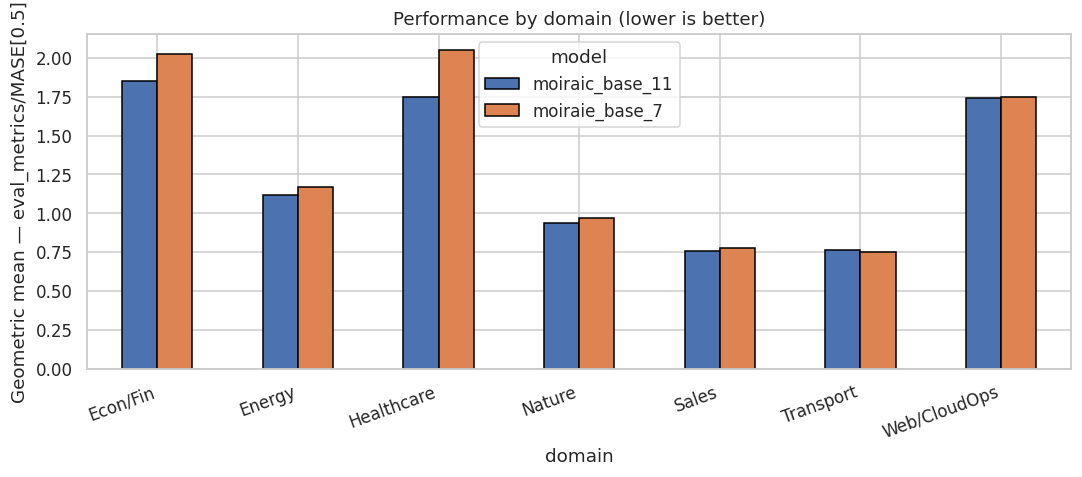

In [23]:
by_domain = by_group(df, PRIMARY_METRIC, 'domain', LOWER_IS_BETTER)
print('=== Avg rank by domain ===')
print(by_domain.pivot(index='domain', columns='model', values='avg_rank').round(3))

piv = by_domain.pivot(index='domain', columns='model', values='geo_mean')
ax = piv.plot(kind='bar', figsize=(10, 4.5), edgecolor='black')
ax.set_ylabel(f'Geometric mean — {PRIMARY_METRIC}')
ax.set_title('Performance by domain (lower is better)')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

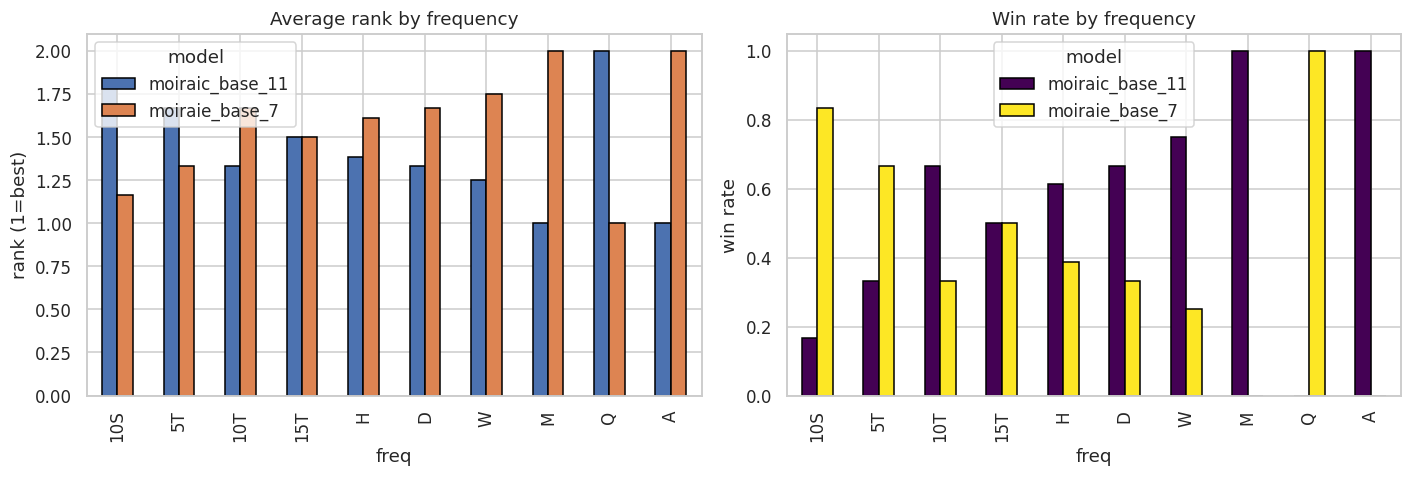

[['10S' 6]
 ['5T' 12]
 ['10T' 6]
 ['15T' 12]
 ['H' 31]
 ['D' 15]
 ['W' 8]
 ['M' 5]
 ['Q' 1]
 ['A' 1]]


In [24]:
by_freq = by_group(df, PRIMARY_METRIC, 'freq', LOWER_IS_BETTER)
FREQ_ORDER = ['10S','5T','10T','15T','30T','H','D','W','M','Q','A']
by_freq['freq'] = pd.Categorical(by_freq['freq'], categories=FREQ_ORDER, ordered=True)
by_freq = by_freq.sort_values('freq')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_freq.pivot(index='freq', columns='model', values='avg_rank').plot(
    kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Average rank by frequency'); axes[0].set_ylabel('rank (1=best)')

by_freq.pivot(index='freq', columns='model', values='win_rate').plot(
    kind='bar', ax=axes[1], edgecolor='black', colormap='viridis')
axes[1].set_title('Win rate by frequency'); axes[1].set_ylabel('win rate')
plt.tight_layout(); plt.show()
print(by_freq.loc[by_freq["model"] == "moiraie_base_7", ["freq", "n_datasets"]].values)

In [30]:
by_freq

,model,freq,mean,median,geo_mean,avg_rank,win_rate,n_datasets
0,moiraie_base_7,10S,4.015640,3.863300,3.590086,1.166667,0.833333,6
1,moiraic_base_11,10S,4.282468,3.563332,3.847867,1.833333,0.166667,6
6,moiraie_base_7,5T,1.436916,0.967344,1.089479,1.333333,0.666667,12
7,moiraic_base_11,5T,1.470163,0.986486,1.133518,1.666667,0.333333,12
2,moiraic_base_11,10T,0.872635,0.923703,0.804951,1.333333,0.666667,6
3,moiraie_base_7,10T,1.123417,0.974098,0.959715,1.666667,0.333333,6
4,moiraic_base_11,15T,0.894760,0.991356,0.864054,1.500000,0.500000,12
5,moiraie_base_7,15T,0.911315,0.963733,0.878022,1.500000,0.500000,12
13,moiraie_base_7,H,1.164597,0.984493,1.036952,1.612903,0.387097,31
12,moiraic_base_11,H,1.113215,0.963059,0.987698,1.387097,0.612903,31


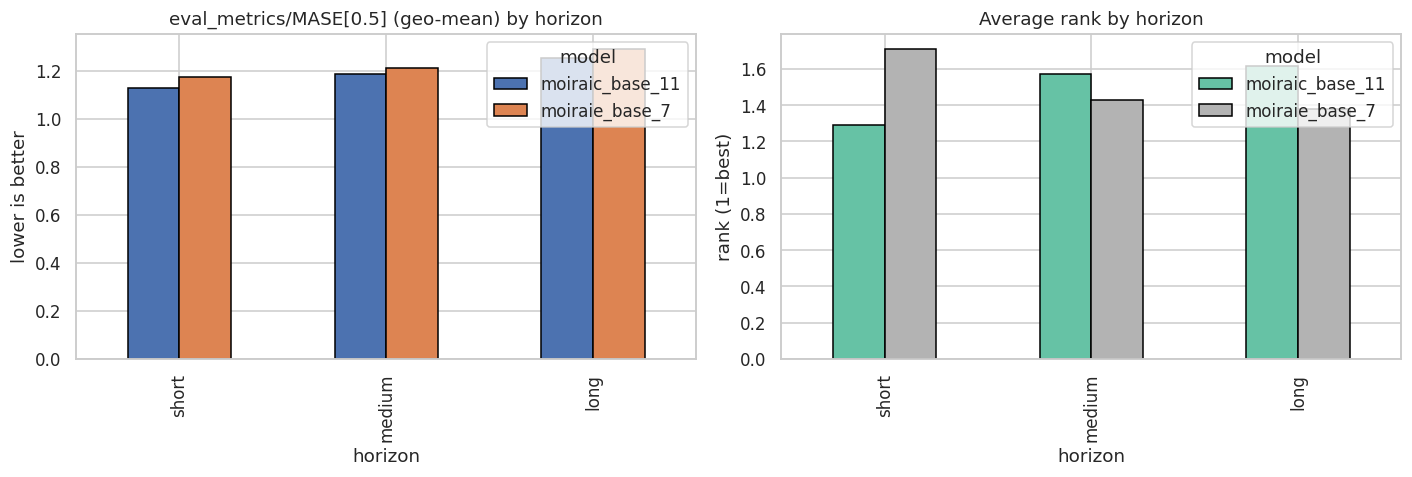

In [25]:
by_hor = by_group(df.dropna(subset=['horizon']), PRIMARY_METRIC, 'horizon', LOWER_IS_BETTER)
by_hor['horizon'] = pd.Categorical(by_hor['horizon'], categories=['short','medium','long'], ordered=True)
by_hor = by_hor.sort_values('horizon')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_hor.pivot(index='horizon', columns='model', values='geo_mean').plot(
    kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title(f'{PRIMARY_METRIC} (geo-mean) by horizon'); axes[0].set_ylabel('lower is better')

by_hor.pivot(index='horizon', columns='model', values='avg_rank').plot(
    kind='bar', ax=axes[1], edgecolor='black', colormap='Set2')
axes[1].set_title('Average rank by horizon'); axes[1].set_ylabel('rank (1=best)')
plt.tight_layout(); plt.show()

In [26]:
pivot = df.pivot_table(index='dataset', columns='model', values=PRIMARY_METRIC)
ranks_all = pivot.rank(axis=1, ascending=LOWER_IS_BETTER)
best = ranks_all.idxmin(axis=1).rename('best_model')
info = df.drop_duplicates('dataset').set_index('dataset')[['domain','horizon']]
combo = info.join(best)
heat = combo.groupby(['domain','horizon','best_model'], observed=True).size().unstack(fill_value=0)
print('Wins per (domain × horizon):')
heat

Wins per (domain × horizon):


best_model            moiraic_base_11  moiraie_base_7
domain       horizon                                 
Econ/Fin     short                  5               1
Energy       short                 11               5
             medium                 4               4
             long                   4               4
Healthcare   short                  5               0
Nature       short                  5               4
             medium                 3               0
             long                   1               2
Sales        short                  3               1
Transport    short                  5               2
             medium                 0               4
             long                   0               4
Web/CloudOps short                  5               3
             medium                 2               4
             long                   3               3

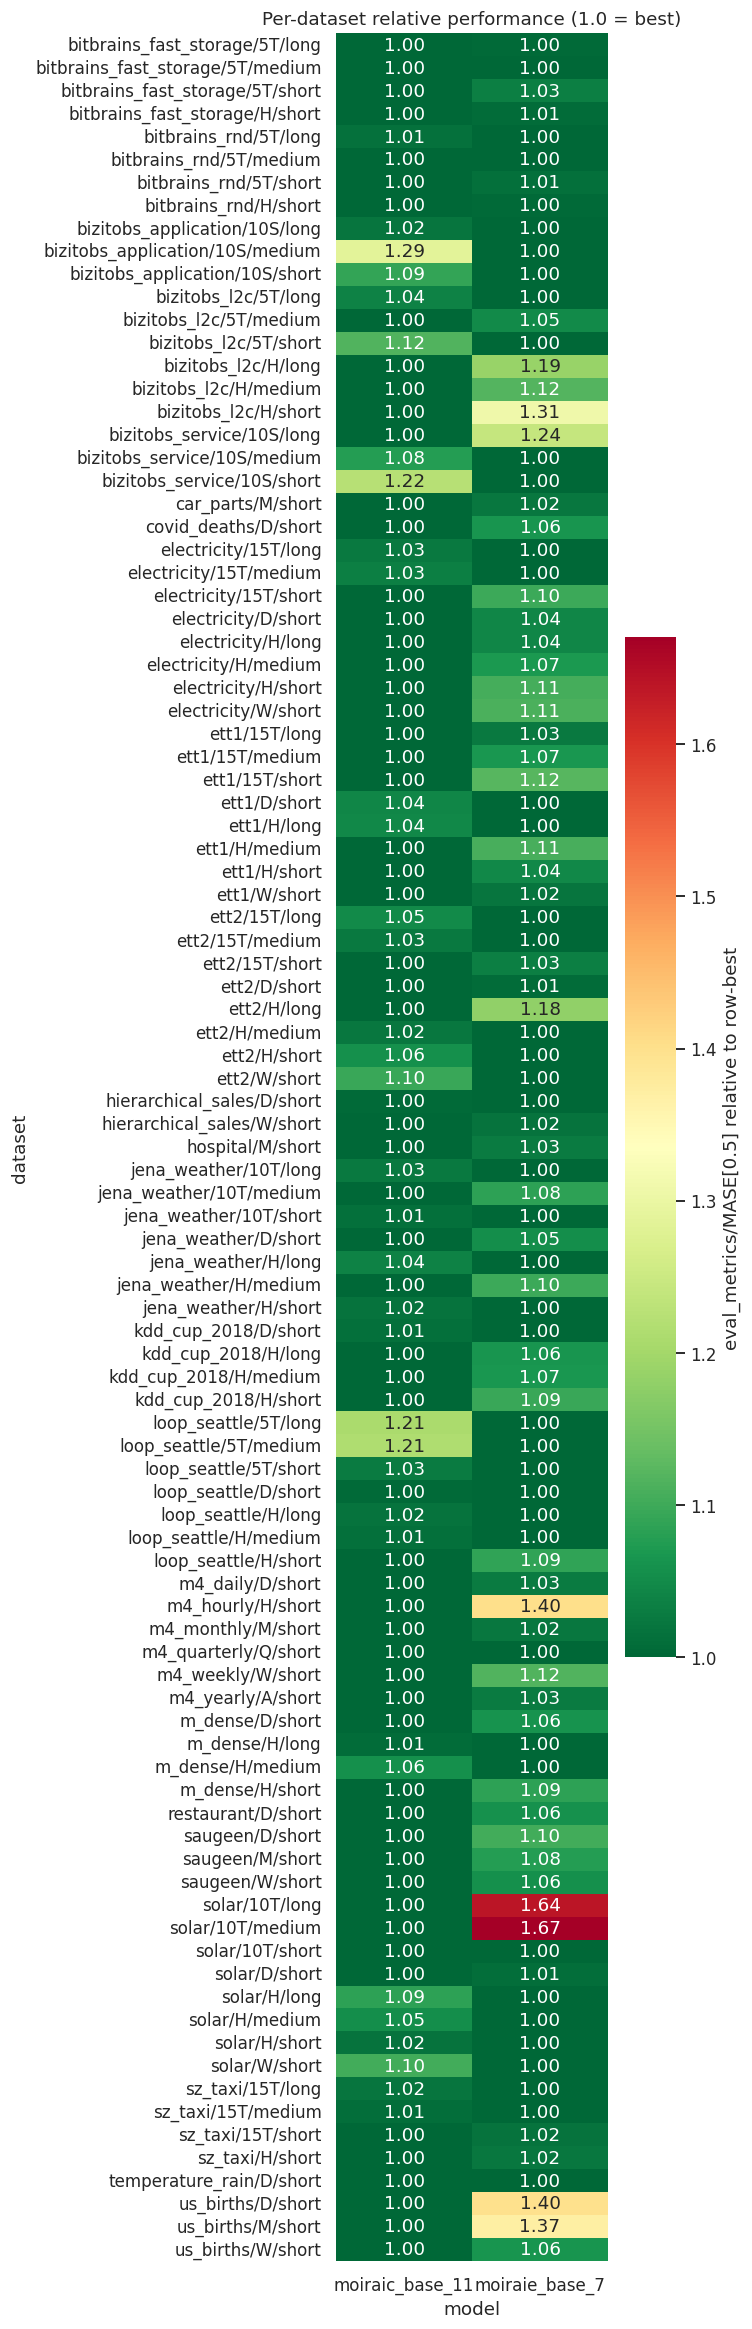

In [27]:
pivot = df.pivot_table(index='dataset', columns='model', values=PRIMARY_METRIC)
norm = pivot.div(pivot.min(axis=1), axis=0)   # 1.0 = best on that row

plt.figure(figsize=(7, max(6, 0.22 * len(norm))))
sns.heatmap(norm, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=1.0, vmax=float(norm.values.max()),
            cbar_kws={'label': f'{PRIMARY_METRIC} relative to row-best'})
plt.title('Per-dataset relative performance (1.0 = best)')
plt.tight_layout(); plt.show()

In [28]:
from itertools import combinations
from scipy.stats import wilcoxon

pivot = df.pivot_table(index='dataset', columns='model', values=PRIMARY_METRIC).dropna()
models = pivot.columns.tolist()

records = []
for a, b in combinations(models, 2):
    if (pivot[a] == pivot[b]).all():
        continue
    stat, p = wilcoxon(pivot[a], pivot[b])
    records.append({
        'A': a, 'B': b,
        f'{a}_better': int((pivot[a] < pivot[b]).sum()),
        f'{b}_better': int((pivot[b] < pivot[a]).sum()),
        'wilcoxon_stat': stat, 'p_value': p,
        'sig_5pct': p < 0.05,
    })
pd.DataFrame(records)

,A,B,moiraic_base_11_better,moiraie_base_7_better,wilcoxon_stat,p_value,sig_5pct
0,moiraic_base_11,moiraie_base_7,56,41,1636.0,0.00771,True


In [29]:
out_path = Path('tsfm_evaluation_report.xlsx')
with pd.ExcelWriter(out_path) as xl:
    summary.round(4).to_excel(xl, sheet_name='overall')
    leader.to_excel(xl, sheet_name='leaderboard')
    by_domain.round(4).to_excel(xl, sheet_name='by_domain', index=False)
    by_freq.round(4).to_excel(xl,   sheet_name='by_frequency', index=False)
    by_hor.round(4).to_excel(xl,    sheet_name='by_horizon', index=False)
    norm.round(3).to_excel(xl,      sheet_name='per_dataset_norm')
print(f'Wrote {out_path.resolve()}')

Wrote /srv/disk00/ctadler/gift-eval/moiraic_eval/tsfm_evaluation_report.xlsx
